# Lab: Data Visualization and Visual Thinking

The U.S. Bureau of Transportation Statistics collects information about scheduled domestic flights. In this lab, you will use the ideas from **Data Visualization and Visual Thinking** to examine a documented sample of 5,000 completed, non-diverted flights from May 2026.


## Learning goals

By the end of this lab, you should be able to:

- load and inspect a CSV file as a Pandas DataFrame;
- distinguish Pandas data types from quantitative and categorical feature types;
- check for missing values;
- create and label a histogram and a bar chart;
- describe a distribution by its typical values, range, and skew;
- use `.describe()` to check estimates made from a histogram;
- explain how histogram bins and axis scales affect a figure; and
- identify conclusions that can and cannot be supported by a sample.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You are still responsible for understanding every part of your submission and checking suggestions against your notebook's output. At the end of the lab, disclose whether you used an AI tool and how you evaluated its advice.


## Dataset

The [U.S. Bureau of Transportation Statistics (BTS) Reporting Carrier On-Time Performance data](https://www.transtats.bts.gov/DL_SelectFields.aspx?QO_fu146_anzr=b0-gvzr&gnoyr_VQ=FGJ) contains 611,735 reported domestic flight records for May 2026. Completed, non-diverted flights with recorded values for all five selected features were eligible for this lab. Canceled flights, diverted flights, and records missing any selected feature were excluded before the sample was drawn.

The course dataset is a reproducible random sample of 5,000 eligible flights. Each observation represents one completed, non-diverted domestic flight in that sample. Because incomplete records were removed before sampling, finding no missing values in the course dataset does not mean that the original BTS data had no missing values. Conclusions from this sample describe the eligible flights and should not automatically be generalized to canceled or diverted flights.

| Feature | Description |
| --- | --- |
| `airline` | Airline that reported the flight |
| `origin_city` | Departure city |
| `destination_city` | Arrival city |
| `distance_miles` | Nonstop flight distance in miles |
| `arrival_delay_minutes` | Minutes between scheduled and actual arrival; negative values mean the flight arrived early |


## Load and preview the data

Import Pandas using the conventional alias `pd`. Read `data/bts_flights_may_2026_sample.csv` into a DataFrame named `flights`.


In [16]:
# Write your code here.
import pandas as pd

flights = pd.read_csv("data/bts_flights_may_2026_sample.csv")

Display the first five rows of the DataFrame.


In [17]:
# Write your code here.
flights.head()

,airline,origin_city,destination_city,distance_miles,arrival_delay_minutes
0,Alaska Airlines,"Anchorage, AK","Chicago, IL",2846,65
1,Alaska Airlines,"Anchorage, AK","Cordova, AK",160,-1
2,Alaska Airlines,"Anchorage, AK","Fairbanks, AK",261,-18
3,Alaska Airlines,"Anchorage, AK","Juneau, AK",571,-21
4,Alaska Airlines,"Anchorage, AK","Juneau, AK",571,-14


Display the last five rows of the DataFrame.


In [18]:
# Write your code here.
flights.tail()

,airline,origin_city,destination_city,distance_miles,arrival_delay_minutes
4995,United Airlines,"West Palm Beach/Palm Beach, FL","Chicago, IL",1144,0
4996,United Airlines,"West Palm Beach/Palm Beach, FL","Houston, TX",956,-22
4997,United Airlines,"West Palm Beach/Palm Beach, FL","Houston, TX",956,-29
4998,United Airlines,"West Palm Beach/Palm Beach, FL","Newark, NJ",1024,-26
4999,United Airlines,"West Palm Beach/Palm Beach, FL","Newark, NJ",1024,7


## Inspect the DataFrame

Display a summary of the DataFrame that includes the feature names, the number of non-missing values, and the Pandas data types.


In [19]:
# Write your code here.
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   airline                5000 non-null   str  
 1   origin_city            5000 non-null   str  
 2   destination_city       5000 non-null   str  
 3   distance_miles         5000 non-null   int64
 4   arrival_delay_minutes  5000 non-null   int64
dtypes: int64(2), str(3)
memory usage: 399.5 KB


**How many observations are in the DataFrame?**

Your answer: 5,000 observations. The ".info()" ouput shows the RangeIndex: 5000 entries.


Count the missing values in every feature.


In [20]:
# Write your code here.
flights.isnull().sum()

airline                  0
origin_city              0
destination_city         0
distance_miles           0
arrival_delay_minutes    0
dtype: int64

## Classify the features

A **quantitative feature** records an amount or measurement for which arithmetic is meaningful. A **categorical feature** assigns observations to groups or labels.


**Complete the table with the Pandas data type and feature type of each feature.**

| Feature | Pandas data type | Feature type |
| --- | --- | --- |
| `airline` | str | categorical |
| `origin_city` | str | categorical |
| `destination_city` | str | categorical |
| `distance_miles` | int64 | quantitative |
| `arrival_delay_minutes` | int64 | quantitative |


## Which destination city is most common in the sample?

Calculate and display the frequency of each destination city. Save the result as `destination_counts`.


In [21]:
# Write your code here.
destination_counts = flights["destination_city"].value_counts()

destination_counts

destination_city
Chicago, IL                      296
Atlanta, GA                      222
Dallas/Fort Worth, TX            210
Denver, CO                       209
Washington, DC                   165
                                ... 
Watertown, SD                      1
Cedar City, UT                     1
Sun Valley/Hailey/Ketchum, ID      1
Carlsbad, CA                       1
Redding, CA                        1
Name: count, Length: 238, dtype: int64

Import `matplotlib.pyplot` using the conventional alias `plt`. Use `.head(10)` on `destination_counts` to select the ten most frequent destination cities, then create a bar chart. Give the figure a descriptive title and label both axes.


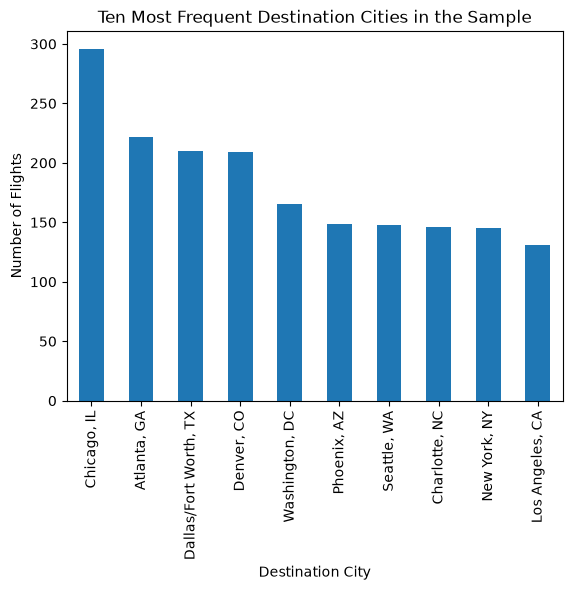

In [22]:
# Write your code here.
import matplotlib.pyplot as plt

destination_counts.head(10).plot(kind="bar")
plt.title("Ten Most Frequent Destination Cities in the Sample")
plt.xlabel("Destination City")
plt.ylabel("Number of Flights")
plt.show()

**Which destination city is most common in the sample?**

Your answer: Chicago, IL is the most common in the sample with 296 flights.


## What was the distribution of arrival delays?

Negative values represent early arrivals, zero represents an on-time arrival, and positive values represent late arrivals.

Create a histogram of `arrival_delay_minutes` using the default number of bins. Give the figure a descriptive title and label both axes.


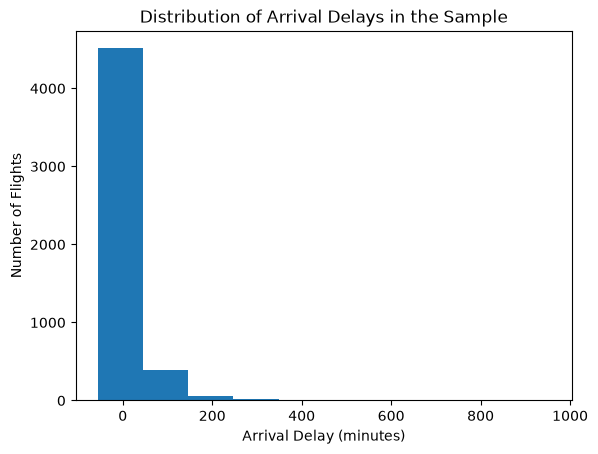

In [23]:
# Write your code here.
flights["arrival_delay_minutes"].plot(kind="hist")
plt.title("Distribution of Arrival Delays in the Sample")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")
plt.show()

**Approximately what arrival-delay value appears most common?**

Your answer: The most common arrival-delay value is near 0 minutes (roughly on-time, slightly early). 


**What is the approximate range from the smallest to the largest arrival-delay value?**

Your answer: The values range from -55 minutes (early) to 950 minutes (late), so a range of about 1,000 minutes.


**Does the arrival-delay distribution appear symmetric or skewed?**

Your answer: The distribution appears skewed to the right (positive). Most flights cluster near zero, but a small number of very late flights create a tail stretching to the right.


Display a numerical summary of `arrival_delay_minutes`.


In [24]:
# Write your code here.
flights["arrival_delay_minutes"].describe()

count    5000.000000
mean        6.098800
std        48.335493
min       -55.000000
25%       -16.000000
50%        -6.000000
75%        10.000000
max       953.000000
Name: arrival_delay_minutes, dtype: float64

Calculate and display the exact mode of `arrival_delay_minutes` using `.mode()`.


In [25]:
# Write your code here.
flights["arrival_delay_minutes"].mode()

0   -8
Name: arrival_delay_minutes, dtype: int64

**How closely did the calculated mode match the most common value you estimated from the histogram?**

Your answer: Very closely. I estimated near 0, the mode is -8. So both point to roughly roughly on-time.


**How closely did the minimum and maximum from `.describe()` match the range you estimated from the histogram?**

Your answer: Very closely. I estimated -55 to 950, ".describe()" shows -55 to 953.


**Is the mean greater than, less than, or approximately equal to the median?**

Your answer: The mean is greater than the median.


**How is the relationship between the mean and median connected to the histogram's shape?**

Your answer: The mean is greater than the median because of the right skew. The extreme late flights pull the mean up while the median stays central.


## Applying the principles: histogram bins

Re-create the arrival-delay histogram using exactly 5 bins.


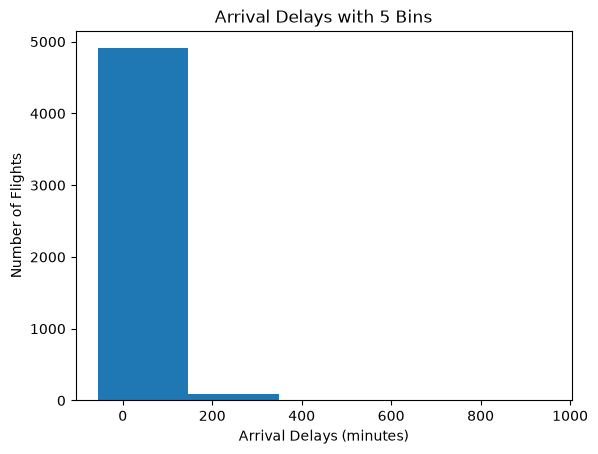

In [26]:
# Write your code here.
flights["arrival_delay_minutes"].plot(kind="hist", bins=5)
plt.title("Arrival Delays with 5 Bins")
plt.xlabel("Arrival Delays (minutes)")
plt.ylabel("Number of Flights")
plt.show()

Re-create the arrival-delay histogram using exactly 25 bins.


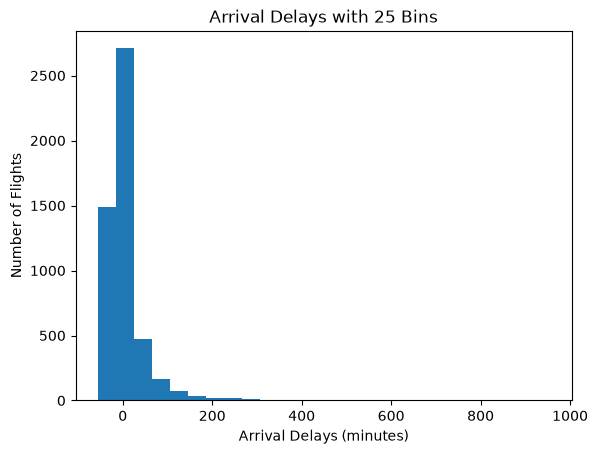

In [27]:
# Write your code here.
flights["arrival_delay_minutes"].plot(kind="hist", bins=25)
plt.title("Arrival Delays with 25 Bins")
plt.xlabel("Arrival Delays (minutes)")
plt.ylabel("Number of Flights")
plt.show()

**What changed when the number of bins was reduced to 5?**

Your answer: With only 5 bins, the bars become very wide and blocky. Almost all flights fall into one huge bin, so the chart lost detail and hid the shape of the distribution near zero.


**What changed when the number of bins was increased to 25?**

Your answer: With 25 bins, the bars become more narrow and revealed the actual shape. There is a tall peak above zero, a clear drop off, and the long thin right tail.


**Which bin setting communicates the distribution most clearly?**

Your answer: The 25 bin setting communicates the distribution most cleanly.


## Applying the principles: a misleading vertical axis

Run both cells below and compare the figures.


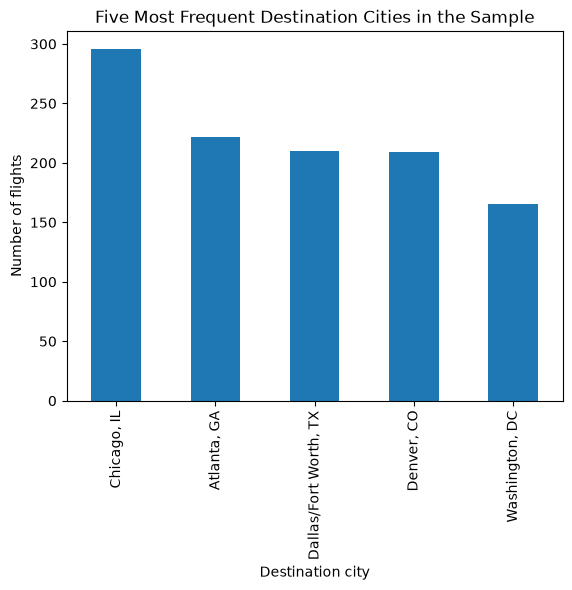

In [28]:
top_destinations = destination_counts.head(5)
top_destinations.plot(kind="bar")
plt.title("Five Most Frequent Destination Cities in the Sample")
plt.xlabel("Destination city")
plt.ylabel("Number of flights")
plt.show()


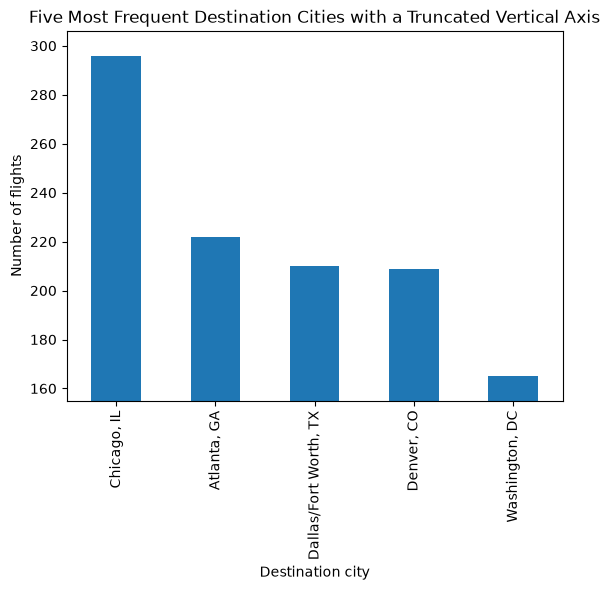

In [29]:
top_destinations.plot(kind="bar")
plt.ylim(top_destinations.min() - 10, top_destinations.max() + 10)
plt.title("Five Most Frequent Destination Cities with a Truncated Vertical Axis")
plt.xlabel("Destination city")
plt.ylabel("Number of flights")
plt.show()


**How does the truncated axis change the apparent differences among the destination cities?**

Your answer: The truncated axis makes the differences between cities look much larger than what they actually are.


**Which chart communicates the counts more honestly?**

Your answer: The first chart is more honest because its y-axis starts at 0, so the bar heights are proportional to the actual flight counts.


## Is this sample representative?

Review the dataset description at the top of the lab before answering these questions.


**What time period is represented by the source data?**

Your answer: The data contains domestic flight records for May 2026.


**Which flights were eligible to be included in the sample?**

Your answer: Completed, non-diverted domestic flights that had recorded values for all 5 selected features.


**Which flights and records were excluded before the sample was selected?**

Your answer: Canceled flights, diverted flights, and any records missing one of the selected features.


**Does finding no missing values in the sample prove that the original BTS data had no missing values?**

Your answer: No. Records with missing values were removed before the sample was drawn, so the sample has no missing values by design.


**Why should conclusions from this sample not automatically be generalized to canceled or diverted flights?**

Your answer: They should not be generalized because canceled and diverted flights were excluded from the sample entirely.


## Choosing a chart

Choose a histogram, bar chart, or pie chart for each question. These questions use features that you did not visualize earlier in the lab.


**Which chart would you use to show the frequency of each airline?**

Your answer: I would use a bar chart. Airline is a categorical feature and bar charts compare frequency of flights for each airline.


**Which chart would you use to show what share of sampled flights departed from each origin city?**

Your answer: I would use a pie chart. A pie chart is better at showing how parts make up a whole (proportions).


**Which chart would you use to show the distribution of flight distances?**

Your answer: I would use a histogram. Flight distances are a quantitative feature, and a histogram shows the distribution of a numeric variable.


## Reflect on AI assistance

Complete one of the following statements.

**If you used an AI tool:**

- Tool used:
- What I asked it to help with:
- One suggestion I checked against my code, chart, or output:
- What I accepted, modified, or rejected—and why:

**If you did not use an AI tool:**

- I did not use an AI tool for this assignment.
- One resource or troubleshooting strategy I used instead was:


Your response: I used Claude AI. I used it to help me understand the pandas and matplotlib code, and how to interpret my histograms and charts. One thing I checked was it had explained that my arrival-delay would be right skewed. So I checked this against my actual histogram and ".describe()" output. The mean ended up being greater than the median and the tail stretched out to 953, which confirmed the skew. I accepted the code and explinations after verifying each result matched my own output. I made sure I understood what each line did rather than just running it.


## Submission checklist

- All code cells run from top to bottom without errors.
- The destination-city bar chart has a descriptive title and labeled axes.
- The default, 5-bin, and 25-bin arrival-delay histograms are included and labeled.
- Both vertical-axis demonstrations are included.
- Every question has one response in its own answer cell.
- The sample questions are answered using the dataset documentation.
- The AI-use reflection is complete and honest.
